![WhatsApp Image 2026-05-08 at 3.45.59 PM.jpeg](<attachment:WhatsApp Image 2026-05-08 at 3.45.59 PM.jpeg>)

![WhatsApp Image 2026-05-08 at 3.46.00 PM.jpeg](<attachment:WhatsApp Image 2026-05-08 at 3.46.00 PM.jpeg>)

![WhatsApp Image 2026-05-08 at 3.46.00 PM(1).jpeg](<attachment:WhatsApp Image 2026-05-08 at 3.46.00 PM(1).jpeg>)

![WhatsApp Image 2026-05-08 at 3.46.01 PM.jpeg](<attachment:WhatsApp Image 2026-05-08 at 3.46.01 PM.jpeg>)


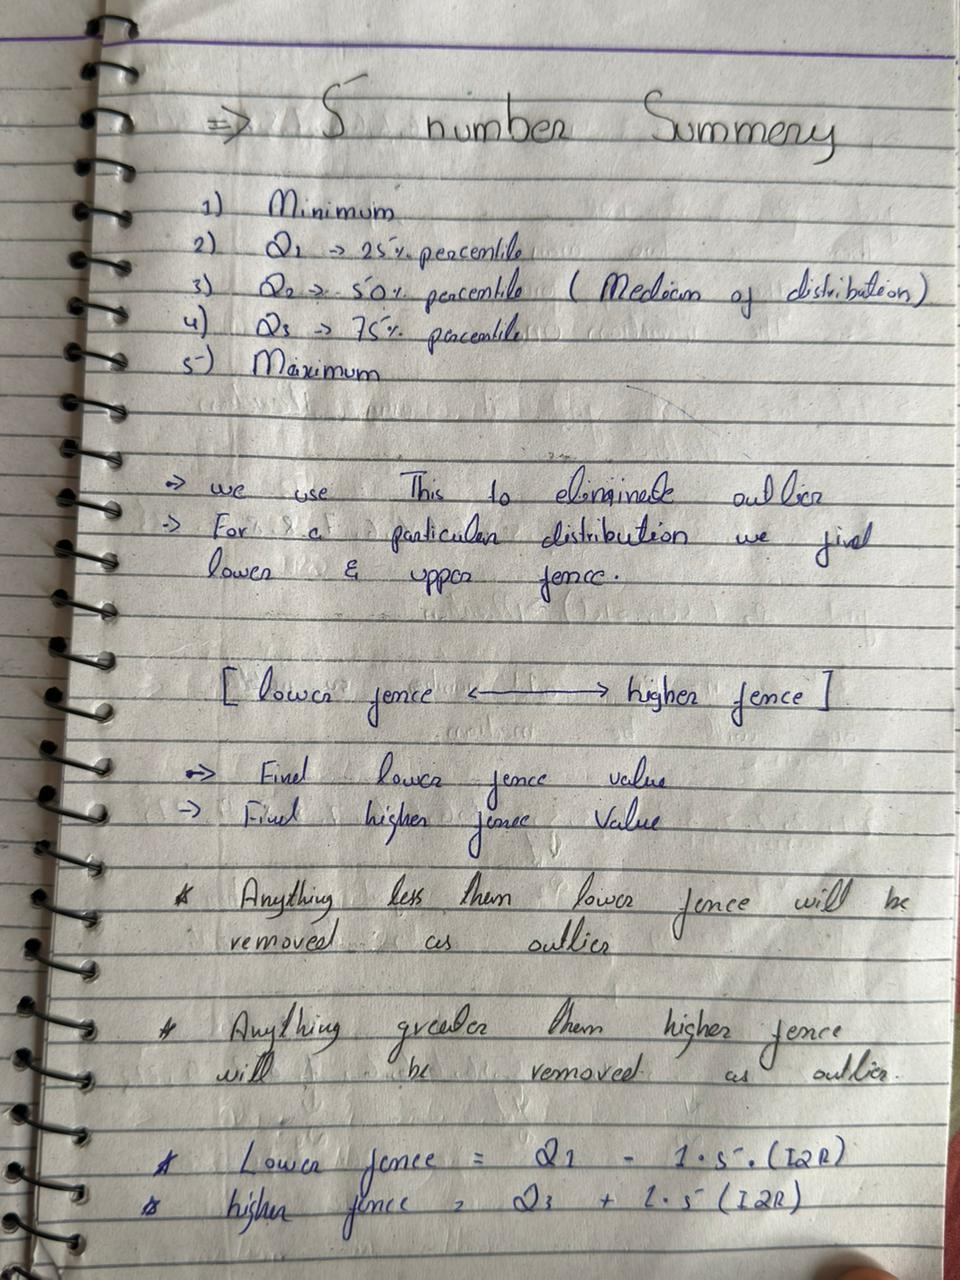
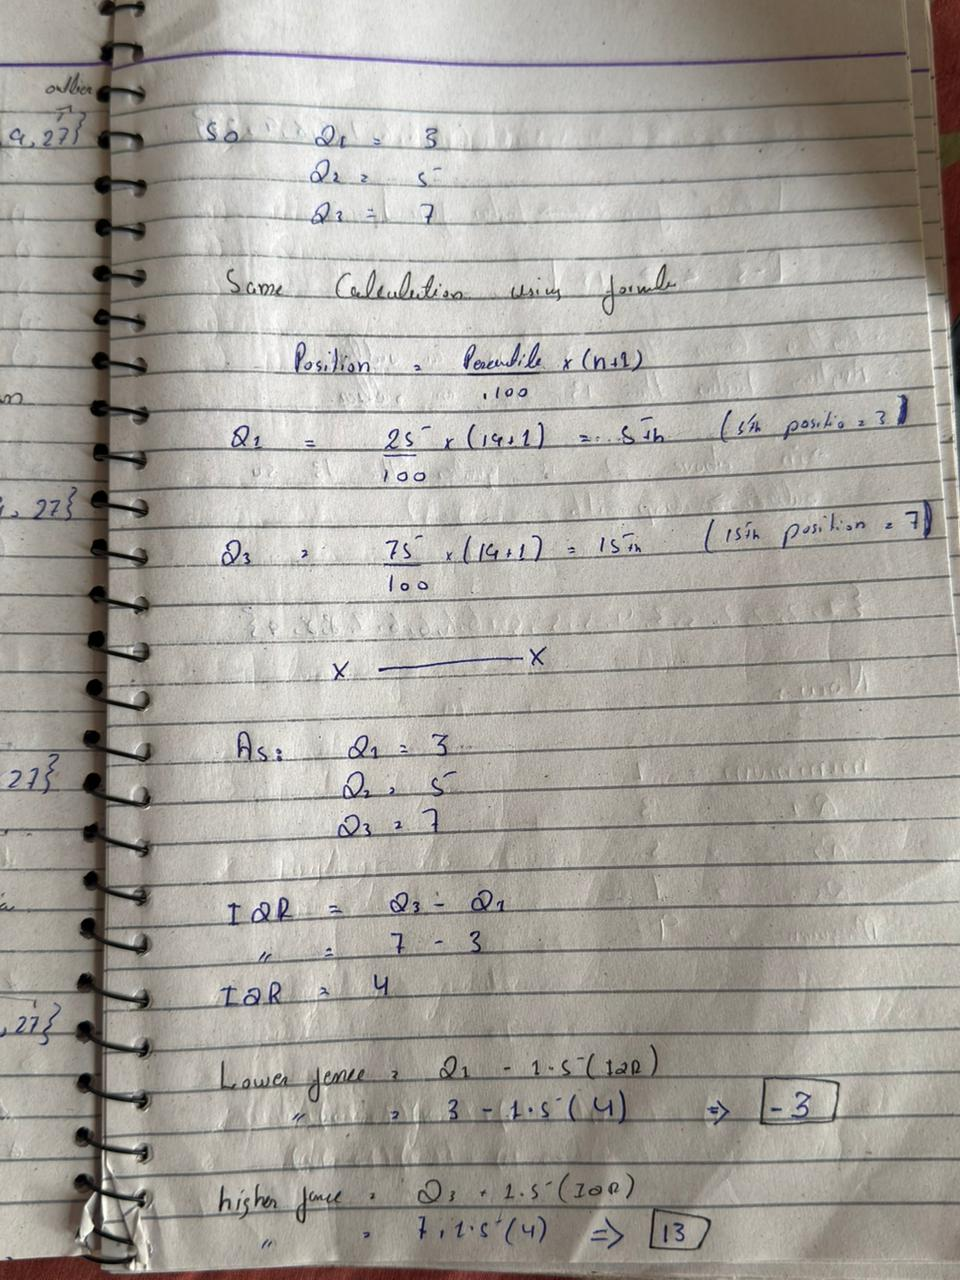
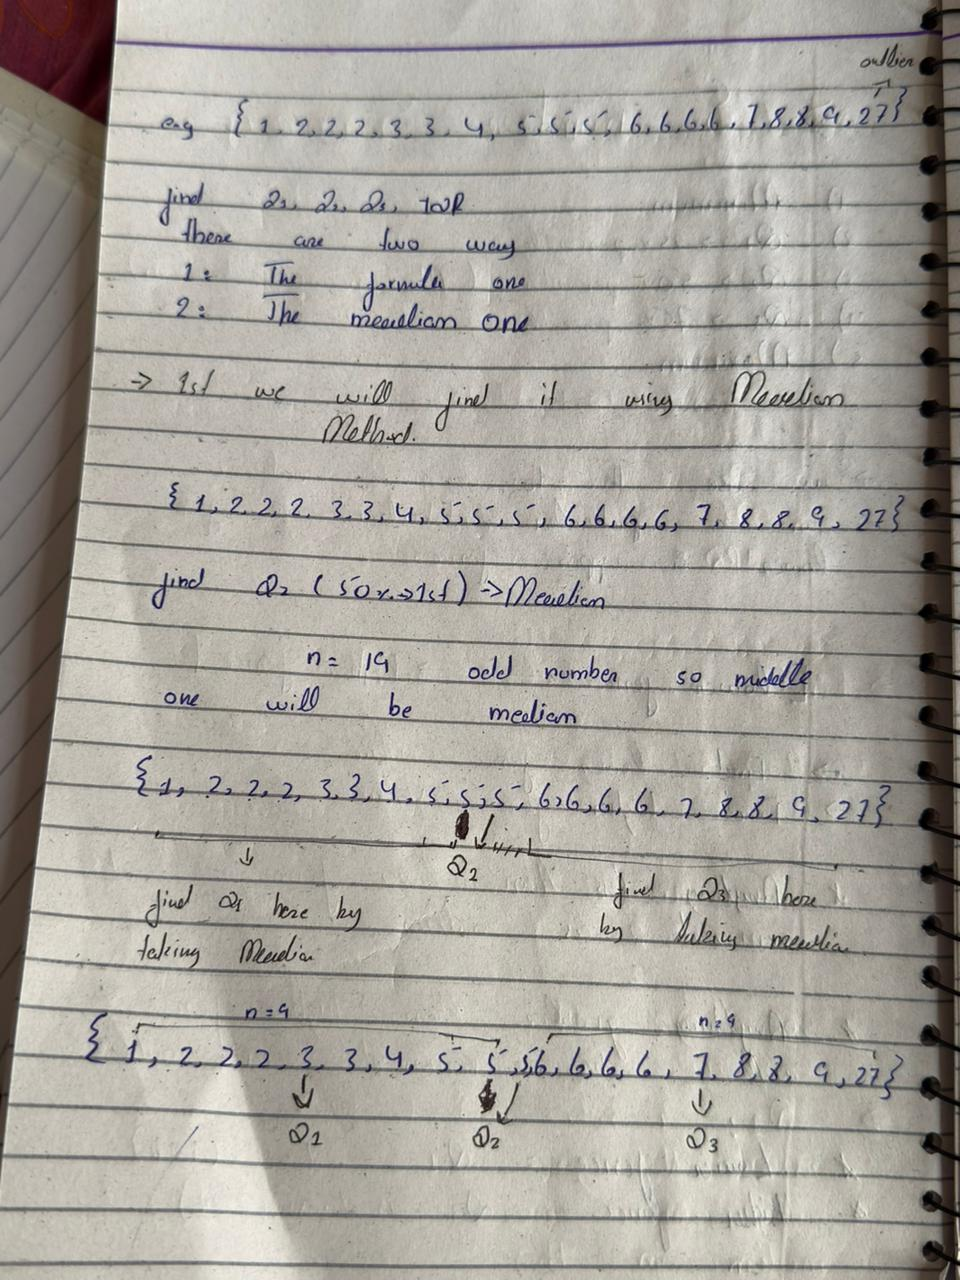
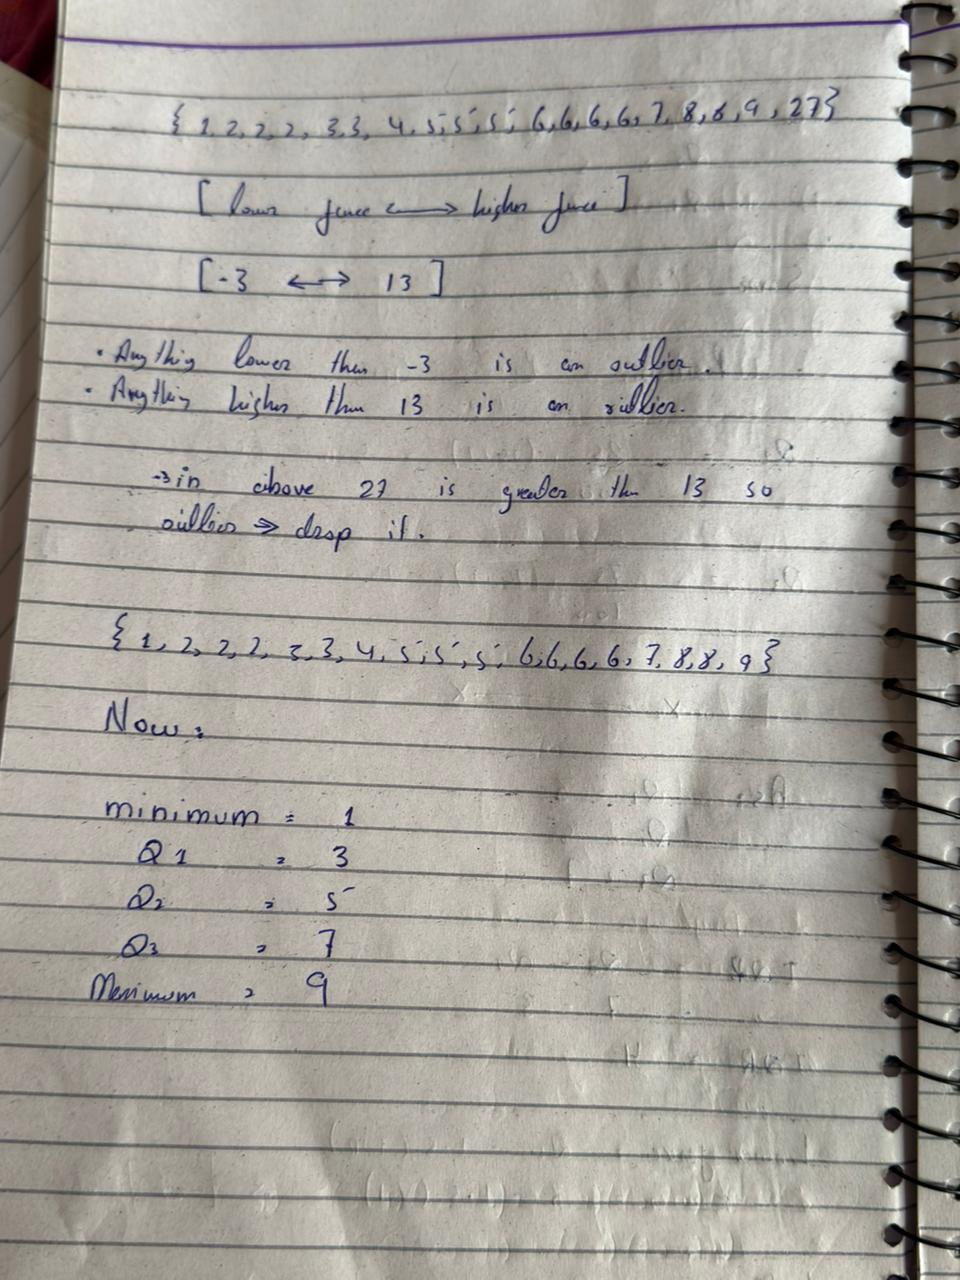

---

# 📐 np.quantile() - NumPy Function

## 🔍 What is it?

`np.quantile()` computes the q-th quantile(s) of an array along a specified axis.

A **quantile** is a value below which a given fraction of data falls.

---

## 📝 Syntax

```python
numpy.quantile(array/data, quantiles, axis=None, out=None, overwrite_input=False, 
               method='linear', keepdims=False, *, interpolation=None)


# Single quantile
np.quantile(data, 0.5)  # median

# Multiple quantiles
np.quantile(data, [0.25, 0.50, 0.75])  # Q1, Median, Q3

```

## 📊 Quantile Values Reference

| quantile value | Meaning |
|:-------:       |---------|
| **0.00**       | Minimum |
| **0.25**       | Q1 (25th percentile) |
| **0.50**       | Median (50th percentile) |
| **0.75**       | Q3 (75th percentile) |
| **1.00**       | Maximum |



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = np.array([10, 12, 13, 14, 15, 100])

# five nmbr summery
Q1 = np.percentile(data,25)
Q2 = np.percentile(data,50)
Q3 = np.percentile(data, 75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * (IQR)

higher_fence = Q3 + 1.5 * (IQR)

print("Q1:", Q1)
print("Q2:", Q2)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Fence:", lower_fence)
print("Upper Fence:", higher_fence)


# Detect outliers
outliers = data[(data < lower_fence) | (data > higher_fence)]
print("Outliers:", outliers)

Q1: 12.25
Q2: 13.5
Q3: 14.75
IQR: 2.5
Lower Fence: 8.5
Upper Fence: 18.5
Outliers: [100]


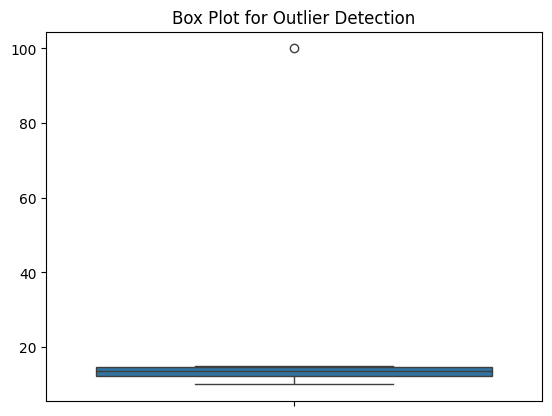

In [7]:
sns.boxplot(data=data)
plt.title("Box Plot for Outlier Detection")
plt.show()

---


In [6]:

np.random.seed(42)

# Normal users
normal = np.random.normal(500, 80, 1000)

# High spenders (outliers)
high_outliers = np.random.normal(1500, 100, 30)

# Very low suspicious values
low_outliers = np.random.normal(50, 10, 20)

# Extreme fraud-like spikes
extreme_outliers = np.array([3000, 3500, 4000])

# Combine everything
data = np.concatenate([
    normal,
    high_outliers,
    low_outliers,
    extreme_outliers
])

print("Total values:", len(data))

print(data)

Total values: 1053
[ 539.73713224  488.93885591  551.81508305 ... 3000.         3500.
 4000.        ]


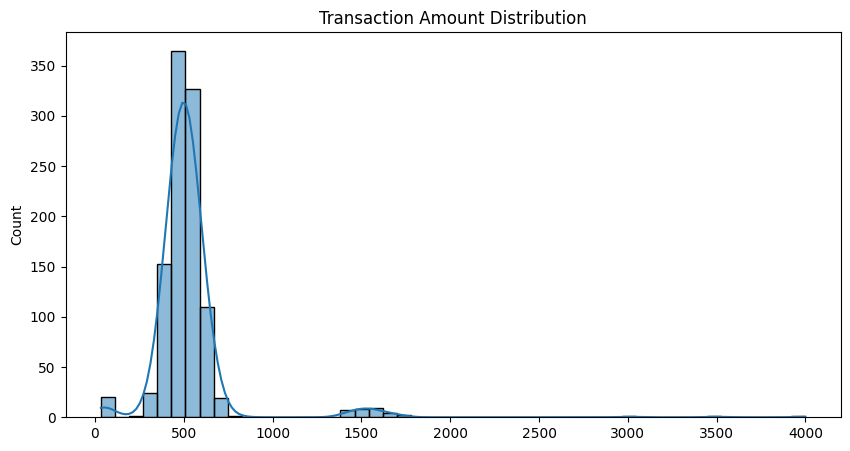

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(data, bins=50, kde=True)

plt.title("Transaction Amount Distribution")
plt.show()

In [10]:
## Five nmbr summery 

min, Q1, Q2, Q3, max = np.quantile(data, [0.0, 0.25, 0.50, 0.75, 1.0])

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
higher_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q2 (Median):", Q2)
print("Q3:", Q3)

print("\nIQR:", IQR)

print("\nLower Fence:", lower_fence)
print("Upper Fence:", higher_fence)


outliers = data[
    (data < lower_fence) |
    (data > higher_fence)
]

print("Number of Outliers:", len(outliers))
print(outliers[:20])   # first 20


Q1: 446.99009928433225
Q2 (Median): 503.6457471923051
Q3: 556.6685157839482

IQR: 109.67841649961599

Lower Fence: 282.47247453490826
Upper Fence: 721.1861405333723
Number of Outliers: 56
[ 808.21851925  240.69861279  746.31046468 1639.93554366 1592.46336829
 1505.96303699 1435.30632223 1569.82233136 1539.34853854 1589.519322
 1563.51718017 1604.95527153 1446.47647884 1631.73940656 1519.75996047
 1707.52608726 1431.08121819 1673.59638032 1519.79107835 1434.85819964]


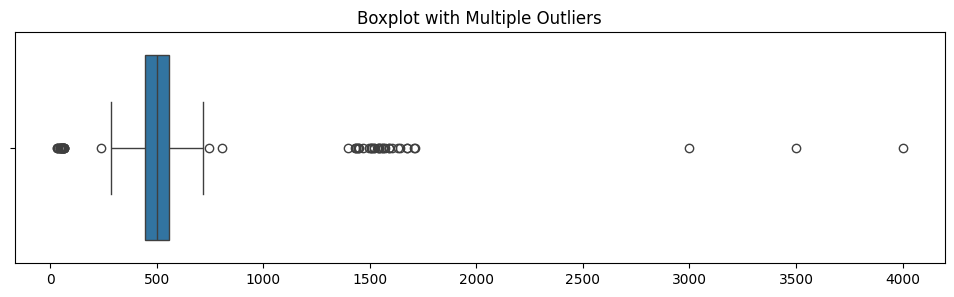

In [11]:
plt.figure(figsize=(12,3))

sns.boxplot(x=data)

plt.title("Boxplot with Multiple Outliers")
plt.show()

In [12]:
# clean Data 

clean_data = data [

    (data >= lower_fence ) & ( data <= higher_fence)
]

print("Original Size:", len(data))
print("Clean Size:", len(clean_data))

Original Size: 1053
Clean Size: 997


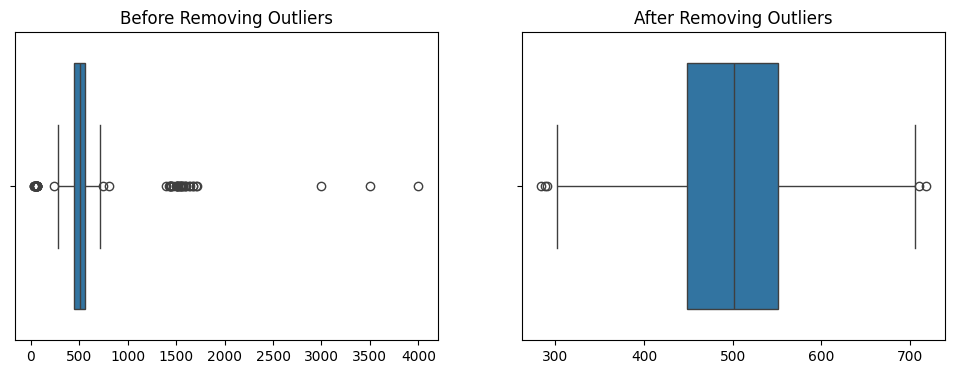

In [13]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.boxplot(x=data, ax=ax[0])
ax[0].set_title("Before Removing Outliers")

sns.boxplot(x=clean_data, ax=ax[1])
ax[1].set_title("After Removing Outliers")

plt.show()

---
---

# On Data set 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 2000

df = pd.DataFrame({
    "salary": np.random.normal(70000, 15000, n),
    "age": np.random.normal(35, 8, n),
    "experience": np.random.normal(10, 5, n),
    "projects": np.random.poisson(6, n),
    "work_hours": np.random.normal(45, 7, n)
})

df.head()

,salary,age,experience,projects,work_hours
0,77450.712295,29.598574,5.682532,5,40.418880
1,67926.035482,33.843851,9.843983,8,49.406335
2,79715.328072,28.660641,10.090084,12,44.591044
3,92845.447846,32.536308,12.363152,3,32.109041
4,66487.699379,19.851083,3.165708,5,52.900158


In [5]:
# Extreme salary outliers
df.loc[np.random.choice(n, 15), "salary"] *= 5

# Extreme age outliers
df.loc[np.random.choice(n, 10), "age"] += 80

# Extreme work hours
df.loc[np.random.choice(n, 12), "work_hours"] += 50

df.head()

,salary,age,experience,projects,work_hours
0,77450.712295,29.598574,5.682532,5,40.418880
1,67926.035482,33.843851,9.843983,8,49.406335
2,79715.328072,28.660641,10.090084,12,44.591044
3,92845.447846,32.536308,12.363152,3,32.109041
4,66487.699379,19.851083,3.165708,5,52.900158


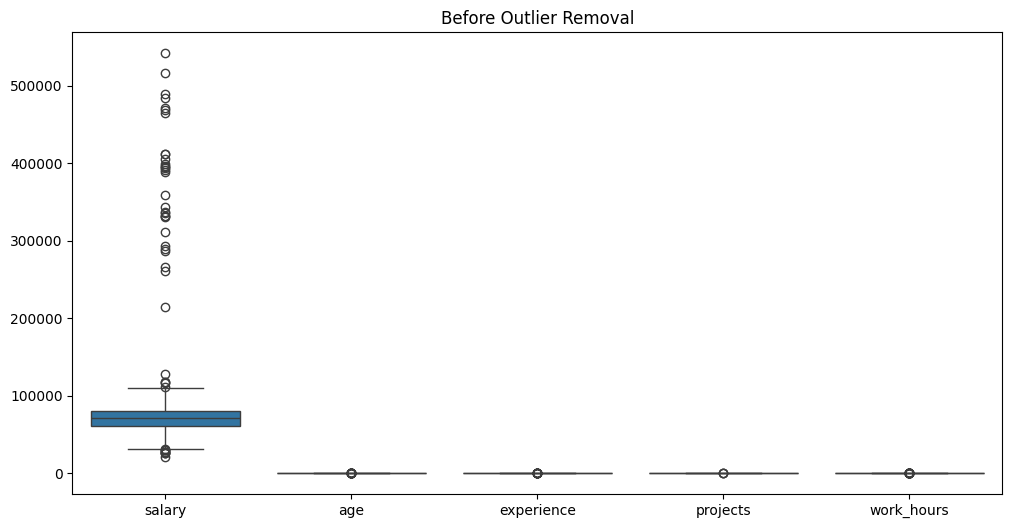

In [6]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.title("Before Outlier Removal")
plt.show()

In [9]:
clean_df = df.copy()

for col in clean_df.columns:

    # -------------------------
    # Five Number Summary
    # -------------------------
    Q1 = clean_df[col].quantile(0.25)
    Q2 = clean_df[col].quantile(0.50)
    Q3 = clean_df[col].quantile(0.75)

    IQR = Q3 - Q1

    # -------------------------
    # Fences
    # -------------------------
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    # -------------------------
    # Remove Outliers
    # -------------------------
    clean_df = clean_df[
        (clean_df[col] >= lower_fence) &
        (clean_df[col] <= upper_fence)
    ]

    print(f"\nColumn: {col}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q2 : {Q2}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Fence: {lower_fence:.2f}")
    print(f"Upper Fence: {upper_fence:.2f}")


Column: salary
Q1: 60826.29
Q2 : 70891.36602950997
Q3: 80698.73
IQR: 19872.44
Lower Fence: 31017.63
Upper Fence: 110507.40

Column: age
Q1: 29.34
Q2 : 35.099994575258
Q3: 40.48
IQR: 11.13
Lower Fence: 12.64
Upper Fence: 57.18

Column: experience
Q1: 6.57
Q2 : 9.822796920009237
Q3: 13.14
IQR: 6.58
Lower Fence: -3.30
Upper Fence: 23.01

Column: projects
Q1: 4.00
Q2 : 6.0
Q3: 8.00
IQR: 4.00
Lower Fence: -2.00
Upper Fence: 14.00

Column: work_hours
Q1: 40.38
Q2 : 45.20422098737667
Q3: 50.13
IQR: 9.74
Lower Fence: 25.77
Upper Fence: 64.74


In [10]:
print("Original Shape:", df.shape)
print("Cleaned Shape:", clean_df.shape)

Original Shape: (2000, 5)
Cleaned Shape: (1866, 5)


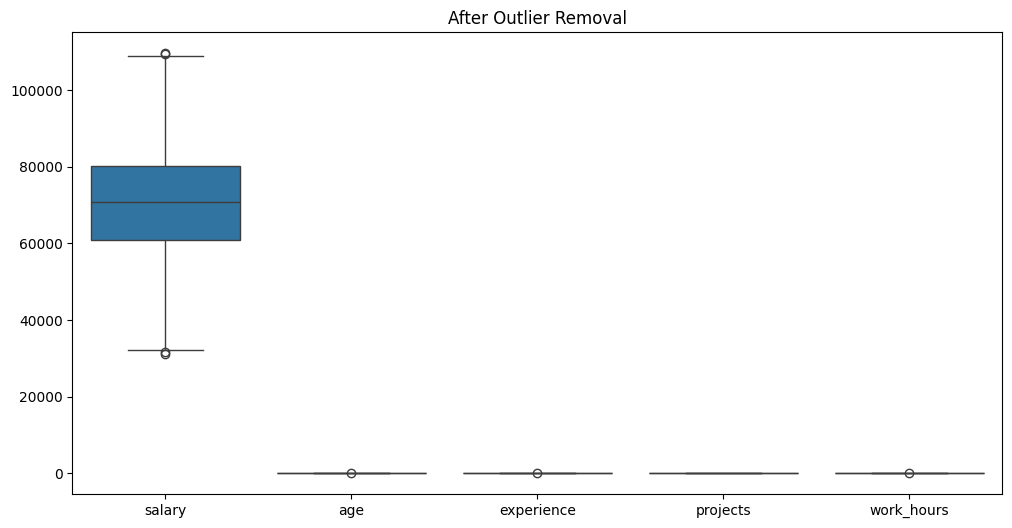

In [11]:
plt.figure(figsize=(12,6))

sns.boxplot(data=clean_df)

plt.title("After Outlier Removal")
plt.show()

In [12]:
print("\nBefore Cleaning:\n")
print(df.describe())

print("\nAfter Cleaning:\n")
print(clean_df.describe())


Before Cleaning:

              salary          age   experience     projects   work_hours
count    2000.000000  2000.000000  2000.000000  2000.000000  2000.000000
mean    75203.542345    35.748460     9.759972     6.053000    45.722044
std     41248.104740    11.456480     4.998318     2.569142     8.903712
min     21380.989899    10.843903    -5.883519     0.000000    21.648689
25%     60826.290625    29.432287     6.566050     4.000000    40.391131
50%     70891.366030    35.056967     9.848950     6.000000    45.200695
75%     80698.734192    40.452261    13.144091     8.000000    50.161319
max    541864.946425   133.560326    25.564551    15.000000   105.822760

After Cleaning:

              salary          age   experience     projects   work_hours
count    1866.000000  1866.000000  1866.000000  1866.000000  1866.000000
mean    70707.746481    34.885689     9.777491     6.005359    45.093092
std     14360.578437     7.912927     4.790562     2.537646     6.842770
min     31134.